# modeling3.ipynb — LOOCV Pipeline (No Data Leakage)

> **Refer to `checkpoints/checkpoint5.md`** for context on why a single train/test split is unreliable at n=43.

**Why LOOCV over a single split:**  
With only 43 patients, a single 25/9/9 split means validation and test scores are based on 9 patients each — one wrong prediction swings accuracy by ~11%. LOOCV rotates every patient through the test position exactly once, training on the remaining 42 each time, giving a much more stable performance estimate.

**How data leakage is prevented:**  
Feature selection (t-test + Mann-Whitney) is performed **inside the loop** on the 42 training patients only for each fold. The held-out patient has zero influence on which peptides are selected. Imputation and scaling also use only training-fold statistics.

## Step 1 — Load the full cleaned dataset

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import ttest_ind, mannwhitneyu
from sklearn.model_selection import LeaveOneOut
from sklearn.base import clone

df        = pd.read_csv("variants_filtered.tsv", sep="\t", index_col=0)
condition = df["Condition"]
X         = df.drop(columns=["Condition"])
y         = condition.map({"Non-severe-COVID-19": 0, "Severe-COVID-19": 1})

print(f"Full dataset : {X.shape[0]} patients × {X.shape[1]} peptides")
print(f"\nCondition counts:")
print(condition.value_counts())
print(f"\nAll 43 patients will rotate through the test position once (LOOCV).")

Full dataset : 43 patients × 101461 peptides

Condition counts:
Condition
Non-severe-COVID-19    25
Severe-COVID-19        18
Name: count, dtype: int64

All 43 patients will rotate through the test position once (LOOCV).


## Step 2 — Define model pipelines

Same three models as `modeling2.ipynb`. `clone()` is used inside the loop to create a fresh unfitted copy of each pipeline for every fold.

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
N_FEATURES   = 200

model_templates = {
    "logistic_regression_l2": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   LogisticRegression(
            penalty="l2", C=1.0, class_weight="balanced",
            max_iter=5000, random_state=RANDOM_STATE,
        )),
    ]),
    "logistic_regression_l1": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   LogisticRegression(
            penalty="l1", C=0.2, solver="liblinear", class_weight="balanced",
            max_iter=5000, random_state=RANDOM_STATE,
        )),
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   RandomForestClassifier(
            n_estimators=500, max_depth=3, min_samples_leaf=2,
            class_weight="balanced", random_state=RANDOM_STATE,
        )),
    ]),
}

print("Model templates defined:")
for name in model_templates:
    print("-", name)

Model templates defined:
- logistic_regression_l2
- logistic_regression_l1
- random_forest


## Step 3 — LOOCV loop

For each of the 43 folds:
1. Hold out 1 patient
2. Run statistical tests on the 42 training patients only
3. Select top 200 peptides from training data only
4. Apply those same 200 peptides to the held-out patient
5. Fit each model pipeline on the 42 training patients
6. Predict the held-out patient

**Note:** this cell takes 10–30 minutes to run because statistical tests are re-run for every fold.

In [3]:
loo = LeaveOneOut()

# Collect predictions for each model across all 43 folds
loocv_results = {
    name: {"y_true": [], "y_pred": [], "y_score": []}
    for name in model_templates
}

for fold, (train_idx, test_idx) in enumerate(loo.split(X)):
    X_train_fold = X.iloc[train_idx]
    X_test_fold  = X.iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold  = y.iloc[test_idx]

    # ── Feature selection on training fold only ───────────
    condition_fold = y_train_fold.map({0: "Non-severe-COVID-19", 1: "Severe-COVID-19"})
    stats_rows = []
    for peptide in X_train_fold.columns:
        sv  = X_train_fold.loc[condition_fold == "Severe-COVID-19",     peptide].dropna()
        nsv = X_train_fold.loc[condition_fold == "Non-severe-COVID-19", peptide].dropna()
        if len(sv) < 3 or len(nsv) < 3:
            stats_rows.append({"Peptide": peptide, "mannwhitney_pvalue": np.nan, "t_pvalue": np.nan})
            continue
        _, t_p = ttest_ind(sv, nsv, equal_var=False, nan_policy="omit")
        try:
            _, mw_p = mannwhitneyu(sv, nsv, alternative="two-sided")
        except ValueError:
            mw_p = np.nan
        stats_rows.append({"Peptide": peptide, "mannwhitney_pvalue": mw_p, "t_pvalue": t_p})

    stats_fold = (
        pd.DataFrame(stats_rows)
        .sort_values(["mannwhitney_pvalue", "t_pvalue"], na_position="last")
        .reset_index(drop=True)
    )
    selected = (
        stats_fold
        .dropna(subset=["mannwhitney_pvalue"])
        .head(N_FEATURES)["Peptide"]
        .tolist()
    )

    X_tr = X_train_fold[selected]
    X_te = X_test_fold[selected]   # same 200 columns, no re-selection

    # ── Train each model and predict the held-out patient ─
    for name, template in model_templates.items():
        pipe = clone(template)     # fresh unfitted copy for this fold
        pipe.fit(X_tr, y_train_fold)
        pred  = pipe.predict(X_te)[0]
        score = pipe.predict_proba(X_te)[0, 1]
        loocv_results[name]["y_true"].append(y_test_fold.iloc[0])
        loocv_results[name]["y_pred"].append(pred)
        loocv_results[name]["y_score"].append(score)

    if (fold + 1) % 10 == 0 or (fold + 1) == len(y):
        print(f"Fold {fold+1:2d}/{len(y)} complete")

print("\nLOOCV complete.")

Fold 10/43 complete
Fold 20/43 complete
Fold 30/43 complete
Fold 40/43 complete
Fold 43/43 complete

LOOCV complete.


## Step 4 — Compare model performance across all 43 folds

In [4]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

comparison_rows = []
for name, res in loocv_results.items():
    y_true  = res["y_true"]
    y_pred  = res["y_pred"]
    y_score = res["y_score"]
    comparison_rows.append({
        "model"            : name,
        "accuracy"         : accuracy_score(y_true, y_pred),
        "precision_severe" : precision_score(y_true, y_pred, zero_division=0),
        "recall_severe"    : recall_score(y_true, y_pred, zero_division=0),
        "f1_severe"        : f1_score(y_true, y_pred, zero_division=0),
        "roc_auc"          : roc_auc_score(y_true, y_score),
    })

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(["f1_severe", "roc_auc", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

print("LOOCV results (aggregated across all 43 folds):")
print(model_comparison.to_string(index=False))

LOOCV results (aggregated across all 43 folds):
                 model  accuracy  precision_severe  recall_severe  f1_severe  roc_auc
logistic_regression_l2  0.906977          0.888889       0.888889   0.888889 0.944444
logistic_regression_l1  0.813953          0.727273       0.888889   0.800000 0.913333
         random_forest  0.813953          0.812500       0.722222   0.764706 0.926667


## Step 5 — Select the best model and inspect per-patient predictions

In [5]:
from sklearn.metrics import classification_report

best_model_name = model_comparison.loc[0, "model"]
best_res        = loocv_results[best_model_name]

predictions_df = pd.DataFrame({
    "patient"            : X.index,
    "true_condition"     : pd.Series(best_res["y_true"]).map({0: "Non-severe", 1: "Severe"}).values,
    "predicted_condition": pd.Series(best_res["y_pred"]).map({0: "Non-severe", 1: "Severe"}).values,
    "severe_probability" : best_res["y_score"],
    "correct"            : [t == p for t, p in zip(best_res["y_true"], best_res["y_pred"])],
})

print(f"Best model: {best_model_name}")
print(f"\nPer-patient LOOCV predictions:")
print(predictions_df.to_string(index=False))

print(f"\n── LOOCV Metrics ({best_model_name}) ──────────────────────")
print(f"Accuracy  : {accuracy_score(best_res['y_true'], best_res['y_pred']):.3f}")
print(f"Precision : {precision_score(best_res['y_true'], best_res['y_pred'], zero_division=0):.3f}")
print(f"Recall    : {recall_score(best_res['y_true'], best_res['y_pred'], zero_division=0):.3f}")
print(f"F1        : {f1_score(best_res['y_true'], best_res['y_pred'], zero_division=0):.3f}")
print(f"ROC-AUC   : {roc_auc_score(best_res['y_true'], best_res['y_score']):.3f}")
print()
print(classification_report(
    best_res["y_true"], best_res["y_pred"],
    target_names=["Non-severe", "Severe"], zero_division=0
))

Best model: logistic_regression_l2

Per-patient LOOCV predictions:
                             patient true_condition predicted_condition  severe_probability  correct
Non-severe-COVID-19.Patient-group-PT     Non-severe              Severe            0.755761    False
             Non-severe-COVID-19.XG1     Non-severe          Non-severe            0.040142     True
            Non-severe-COVID-19.XG10     Non-severe          Non-severe            0.244496     True
            Non-severe-COVID-19.XG11     Non-severe          Non-severe            0.018095     True
            Non-severe-COVID-19.XG13     Non-severe          Non-severe            0.005529     True
            Non-severe-COVID-19.XG14     Non-severe          Non-severe            0.025622     True
            Non-severe-COVID-19.XG15     Non-severe          Non-severe            0.008815     True
            Non-severe-COVID-19.XG16     Non-severe          Non-severe            0.000277     True
            Non-severe-C

## Step 6 — Confusion Matrix

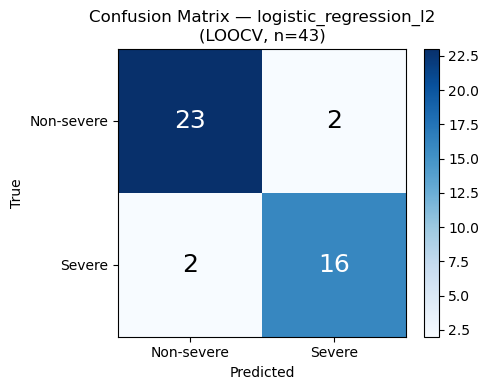

True Negatives  (Non-severe → Non-severe): 23
False Positives (Non-severe → Severe)    : 2
False Negatives (Severe → Non-severe)    : 2
True Positives  (Severe → Severe)        : 16


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm     = confusion_matrix(best_res["y_true"], best_res["y_pred"])
labels = ["Non-severe", "Severe"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {best_model_name}\n(LOOCV, n=43)")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                fontsize=18, color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Non-severe → Non-severe): {tn}")
print(f"False Positives (Non-severe → Severe)    : {fp}")
print(f"False Negatives (Severe → Non-severe)    : {fn}")
print(f"True Positives  (Severe → Severe)        : {tp}")

## Step 7 — Precision-Recall Curve

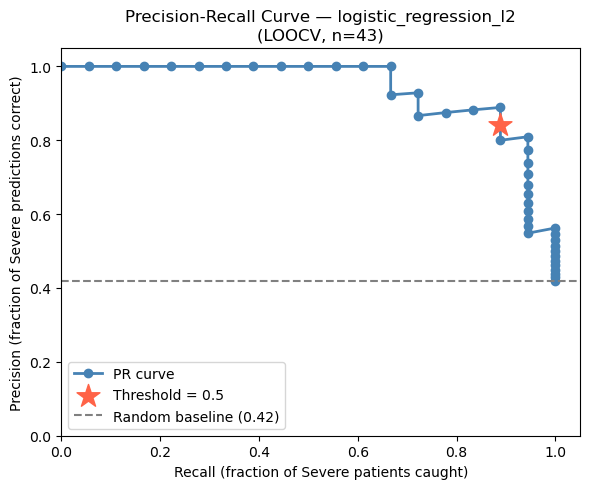

In [7]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(
    best_res["y_true"], best_res["y_score"]
)
default_idx = np.argmin(np.abs(thresholds - 0.5))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_vals, precision_vals, marker="o", color="steelblue", linewidth=2, label="PR curve")
ax.scatter(recall_vals[default_idx], precision_vals[default_idx],
           marker="*", s=300, color="tomato", zorder=5, label="Threshold = 0.5")
ax.axhline(np.mean(best_res["y_true"]), linestyle="--", color="grey",
           label=f"Random baseline ({np.mean(best_res['y_true']):.2f})")
ax.set_xlabel("Recall (fraction of Severe patients caught)")
ax.set_ylabel("Precision (fraction of Severe predictions correct)")
ax.set_title(f"Precision-Recall Curve — {best_model_name}\n(LOOCV, n=43)")
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## Step 8 — Compare LOOCV results with modeling2.ipynb single-split results

In [8]:
modeling2_results = pd.read_csv("models/checkpoint4_model_comparison.tsv", sep="\t")
modeling2_best    = modeling2_results.iloc[0]

best_loocv = model_comparison.iloc[0]

comparison = pd.DataFrame({
    "leaky single-split (modeling.ipynb)"    : modeling2_results.iloc[0][["accuracy","precision_severe","recall_severe","f1_severe","roc_auc"]],
    "corrected single-split (modeling2.ipynb)": {
        "accuracy": 0.889, "precision_severe": 0.800,
        "recall_severe": 1.000, "f1_severe": 0.889, "roc_auc": 0.950
    },
    "LOOCV (modeling3.ipynb)"                : best_loocv[["accuracy","precision_severe","recall_severe","f1_severe","roc_auc"]],
}).T

print(f"Best LOOCV model         : {best_model_name}")
print(f"Best single-split model  : {modeling2_best['model']}")
print()
print(comparison.round(3).to_string())

Best LOOCV model         : logistic_regression_l2
Best single-split model  : logistic_regression_l2

                                          accuracy precision_severe recall_severe f1_severe   roc_auc
leaky single-split (modeling.ipynb)            1.0              1.0           1.0       1.0       1.0
corrected single-split (modeling2.ipynb)     0.889              0.8           1.0     0.889      0.95
LOOCV (modeling3.ipynb)                   0.906977         0.888889      0.888889  0.888889  0.944444


## Step 9 — Save LOOCV results and retrain best model on all 43 patients

Since LOOCV uses all data for evaluation, there is no held-out test set. We retrain the best model on all 43 patients using the full feature selection pipeline — this is the final model for feature importance inspection.

In [9]:
import joblib

MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(exist_ok=True)

# Save LOOCV comparison and per-patient predictions
model_comparison.to_csv(MODEL_DIR / "modeling3_loocv_comparison.tsv", sep="\t", index=False)
predictions_df.to_csv(MODEL_DIR / "modeling3_loocv_predictions.tsv", sep="\t", index=False)

# Retrain the best model on all 43 patients
# Feature selection on the full dataset (acceptable here — this model is for inspection only,
# not evaluation; performance was already estimated by LOOCV above)
condition_all = y.map({0: "Non-severe-COVID-19", 1: "Severe-COVID-19"})
stats_all = []
for peptide in X.columns:
    sv  = X.loc[condition_all == "Severe-COVID-19",     peptide].dropna()
    nsv = X.loc[condition_all == "Non-severe-COVID-19", peptide].dropna()
    if len(sv) < 3 or len(nsv) < 3:
        stats_all.append({"Peptide": peptide, "mannwhitney_pvalue": np.nan, "t_pvalue": np.nan})
        continue
    _, t_p = ttest_ind(sv, nsv, equal_var=False, nan_policy="omit")
    try:
        _, mw_p = mannwhitneyu(sv, nsv, alternative="two-sided")
    except ValueError:
        mw_p = np.nan
    stats_all.append({"Peptide": peptide, "mannwhitney_pvalue": mw_p, "t_pvalue": t_p})

stats_all_df = (
    pd.DataFrame(stats_all)
    .sort_values(["mannwhitney_pvalue", "t_pvalue"], na_position="last")
    .reset_index(drop=True)
)
final_peptides = stats_all_df.dropna(subset=["mannwhitney_pvalue"]).head(N_FEATURES)["Peptide"].tolist()

final_model = clone(model_templates[best_model_name])
final_model.fit(X[final_peptides], y)

joblib.dump(final_model, MODEL_DIR / "modeling3_final_model.joblib")
(MODEL_DIR / "modeling3_best_model_name.txt").write_text(best_model_name + "\n")
pd.Series(final_peptides).to_csv(MODEL_DIR / "modeling3_selected_peptides.txt", index=False, header=False)

print("Saved:")
print("  modeling3_loocv_comparison.tsv   — LOOCV metrics for all 3 models")
print("  modeling3_loocv_predictions.tsv  — per-patient predictions from best model")
print("  modeling3_final_model.joblib     — best model retrained on all 43 patients")
print("  modeling3_best_model_name.txt    — best model name")
print("  modeling3_selected_peptides.txt  — 200 peptides selected from full dataset")

Saved:
  modeling3_loocv_comparison.tsv   — LOOCV metrics for all 3 models
  modeling3_loocv_predictions.tsv  — per-patient predictions from best model
  modeling3_final_model.joblib     — best model retrained on all 43 patients
  modeling3_best_model_name.txt    — best model name
  modeling3_selected_peptides.txt  — 200 peptides selected from full dataset
